In [3]:
import pandas as pd
import numpy as np
import zipfile
import requests
from io import BytesIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

response = requests.get(url, verify=False)

z = zipfile.ZipFile(BytesIO(response.content))

ratings = pd.read_csv(
    z.open("ml-latest-small/ratings.csv")
)

movies = pd.read_csv(
    z.open("ml-latest-small/movies.csv")
)

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

display(movies.head())
display(ratings.head())

Ratings shape: (100836, 4)
Movies shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
# Prepare recommendation data

movie_counts = ratings['movieId'].value_counts()

popular_movies = movie_counts[movie_counts >= 20].index

ratings_filtered = ratings[
    ratings['movieId'].isin(popular_movies)
].copy()

user_movie_matrix = ratings_filtered.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("Filtered ratings:", ratings_filtered.shape)
print("User-Movie Matrix:", user_movie_matrix.shape)

Filtered ratings: (67898, 4)
User-Movie Matrix: (610, 1297)


In [5]:
from sklearn.neighbors import NearestNeighbors

K_values = [3, 5, 10, 15]

knn_models = {}

for k in K_values:
    model = NearestNeighbors(
        n_neighbors=k + 1,
        metric='cosine',
        algorithm='brute'
    )
    
    model.fit(user_movie_matrix.fillna(0).T)
    knn_models[k] = model

print("KNN models trained for:", K_values)

KNN models trained for: [3, 5, 10, 15]


In [6]:
movie_ids = user_movie_matrix.columns.tolist()

def recommend_movies(movie_id, k=5):
    model = knn_models[k]
    movie_index = movie_ids.index(movie_id)

    distances, indices = model.kneighbors(
        user_movie_matrix.fillna(0).T.iloc[movie_index:movie_index+1],
        n_neighbors=k + 1
    )

    recommended_ids = [movie_ids[i] for i in indices[0][1:]]

    return movies[
        movies['movieId'].isin(recommended_ids)
    ][['movieId', 'title', 'genres']].reset_index(drop=True)

toy_story_id = movies[
    movies['title'].str.contains("Toy Story", case=False, na=False)
]['movieId'].iloc[0]

print("Toy Story ID:", toy_story_id)
display(recommend_movies(toy_story_id, k=5))

Toy Story ID: 1


,movieId,title,genres
0,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
1,356,Forrest Gump (1994),Comedy|Drama|Romance|War
2,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
3,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
4,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy


In [7]:
quality_results = []

for k in K_values:
    model = knn_models[k]

    distances, indices = model.kneighbors(
        user_movie_matrix.fillna(0).T,
        n_neighbors=k + 1
    )

    avg_distance = distances[:, 1:].mean()
    avg_similarity = 1 - avg_distance

    quality_results.append({
        'K': k,
        'Average Distance': avg_distance,
        'Average Similarity': avg_similarity
    })

quality_df = pd.DataFrame(quality_results)

display(quality_df)

,K,Average Distance,Average Similarity
0,3,0.478984,0.521016
1,5,0.495427,0.504573
2,10,0.519769,0.480231
3,15,0.534797,0.465203


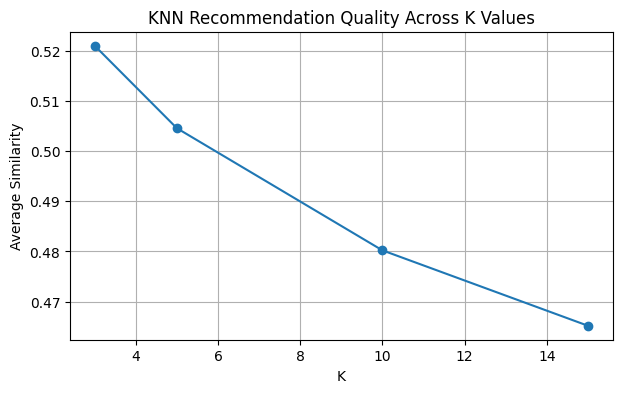

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    quality_df['K'],
    quality_df['Average Similarity'],
    marker='o'
)

plt.xlabel("K")
plt.ylabel("Average Similarity")
plt.title("KNN Recommendation Quality Across K Values")
plt.grid(True)
plt.show()

In [9]:
best_k = quality_df.loc[
    quality_df['Average Similarity'].idxmax(), 'K'
]

print("Best K:", int(best_k))
print("Highest Average Similarity:",
      round(quality_df['Average Similarity'].max(), 4))

Best K: 3
Highest Average Similarity: 0.521


In [10]:
print("Final Recommendations using K =", int(best_k))

final_recommendations = recommend_movies(
    toy_story_id,
    k=int(best_k)
)

display(final_recommendations)

Final Recommendations using K = 3


,movieId,title,genres
0,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
1,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
2,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy


In [11]:
comparison_df = quality_df.copy()

comparison_df['Rank'] = (
    comparison_df['Average Similarity']
    .rank(ascending=False)
    .astype(int)
)

comparison_df = comparison_df.sort_values('K')

display(comparison_df)

print("Best K:", int(best_k))
print("Best Average Similarity:", round(
    quality_df['Average Similarity'].max(), 4
))

,K,Average Distance,Average Similarity,Rank
0,3,0.478984,0.521016,1
1,5,0.495427,0.504573,2
2,10,0.519769,0.480231,3
3,15,0.534797,0.465203,4


Best K: 3
Best Average Similarity: 0.521


In [12]:
comparison_df.to_csv(
    "day16_knn_k_comparison.csv",
    index=False
)

final_recommendations.to_csv(
    "day16_movie_recommendations.csv",
    index=False
)

print("Files saved successfully!")
print("1. day16_knn_k_comparison.csv")
print("2. day16_movie_recommendations.csv")

Files saved successfully!
1. day16_knn_k_comparison.csv
2. day16_movie_recommendations.csv


In [13]:
print("DAY 16 - MOVIE RECOMMENDATION WITH KNN")
print("----------------------------------------")
print("Dataset: MovieLens")
print("Ratings:", ratings.shape[0])
print("Movies:", movies.shape[0])
print("Filtered ratings:", ratings_filtered.shape[0])
print("K values tested:", K_values)
print("Best K:", int(best_k))
print("Best Average Similarity:", round(quality_df['Average Similarity'].max(), 4))
print("Recommendation example: Toy Story")

DAY 16 - MOVIE RECOMMENDATION WITH KNN
----------------------------------------
Dataset: MovieLens
Ratings: 100836
Movies: 9742
Filtered ratings: 67898
K values tested: [3, 5, 10, 15]
Best K: 3
Best Average Similarity: 0.521
Recommendation example: Toy Story
